### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_6613/767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


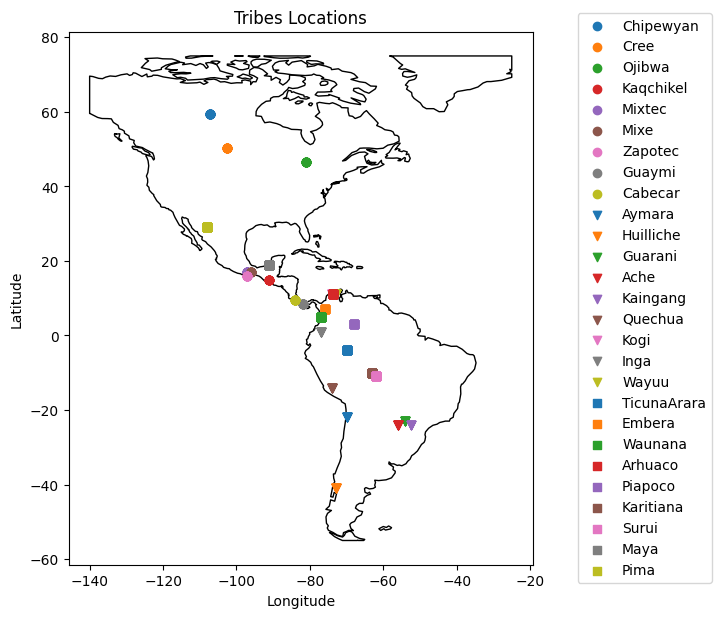

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
import numpy as np
X = df.iloc[:, 8:]
print(X)
beta_est = np.linalg.solve(X.T @ X, X.T @ longitude)
print(beta_est)

             L1.125  L1.130  L1.135  L1.140  L1.142  L1.145  L1.150  \
Chipewyan29       0       0       0       0       0       1       0   
Chipewyan31       0       0       0       0       0       1       0   
Chipewyan33       0       0       0       0       0       1       0   
Chipewyan35       0       0       0       0       0       1       0   
Chipewyan37       0       0       0       0       0       0       0   
...             ...     ...     ...     ...     ...     ...     ...   
Pima1043          0       0       0       0       0       1       0   
Pima1045          0       0       0       0       0       1       0   
Pima1047          0       0       0       0       0       1       0   
Pima1049          0       0       0       0       0       1       0   
Pima1051          0       0       0       0       0       1       0   

             L1.150.940397350993  L1.152  L1.155  ...  L677.255.553287981859  \
Chipewyan29                    0       0       0  ...              

LinAlgError: Singular matrix

The problem we are having is Singular matrix error .
We have $rank(X) = rank (XTX)$ and $rank(X) < p$ and $X^TX \in R^{p*p}$  So  matrix $X^TX$ is not inverible .

As a result, we cannot an exact solution for $\beta$ .

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [4]:
estimation = np.linalg.lstsq(X.T @ X, X.T @ longitude)
print(f"the coefficients of beta using np.linalg.lstsq are {estimation[0]}")


the coefficients of beta using np.linalg.lstsq are [-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


Using np.linalg.lstsq instead of np.linalg.solve we are no longer having the singular matrix error .

While np.linalg solves for a unique exact solution of a system $AX = B$, it works only when $rank(A) = n$ where n is the size of  $X $ .

And it fails when $rank(A) < n$ , because we have an infinite number of solutions .

When we are in this situation, np.linalg.lstsq solves this problem searching for  the minimum norm least squares solution x which minimizes both |x|2 and $\Vert b - Ax{\Vert}_2$.


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [5]:
from sklearn.linear_model import LinearRegression
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


When re-centering data systematically, the intercept with the centered data is simply the average longitude for an average person whereas the intercept without recentering the data is the expectation of the longitude when all predictors are equal one which doesn't have a meaning in this context (all genetic markers are set to zero ).

Further more, recentering the predictors improves numerical stability .

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

When we have many features ( the genetic markers in pur case), we cannot have a good visualization of the data ( we can't visualize data with more than 3D) .

The PCA solves this problem, it reduces the dimensions of the data leaving only relevant ones , by projecting them onto 2D spaces for example which can helps us
to understand how the data are distriuted in the data set .

Statistically, the PCA, calculates the main components, which are the eigenvectors of the covariance matrix ( they are ranked by the eigenvalues assoiated to them).
The first PC captures most of the variance in the dataset, and the other ones completes the other layers of the variance .

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

/tmp/ipykernel_6613/4263950658.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


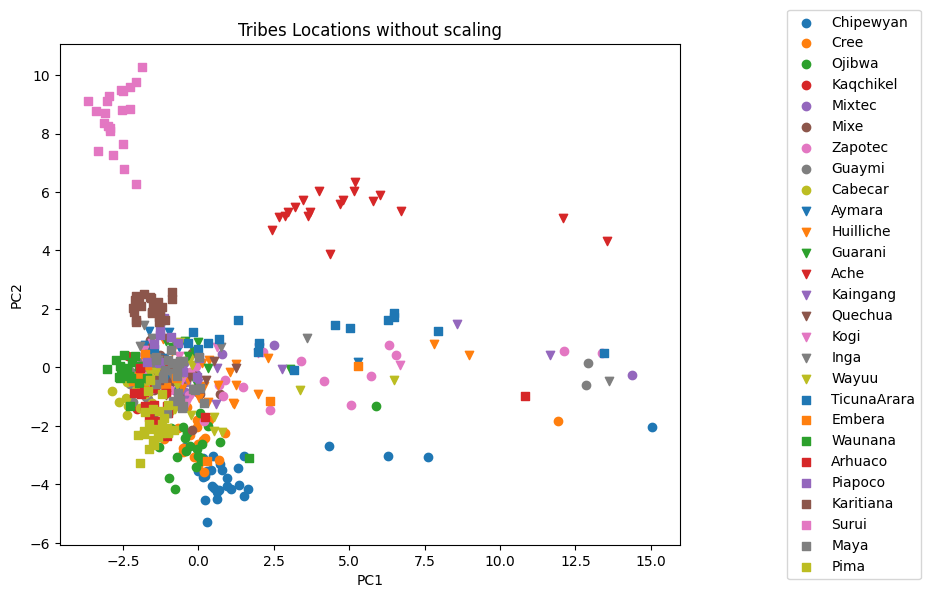

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)
reduced_X = pca.transform(X)

#plotting

fig, ax = plt.subplots(figsize=(8.0, 6.5))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    idx = (df.iloc[:, 2] == tribe)
    ax.scatter(reduced_X[idx, 0], reduced_X[idx, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations without scaling')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

/tmp/ipykernel_6613/2735800925.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


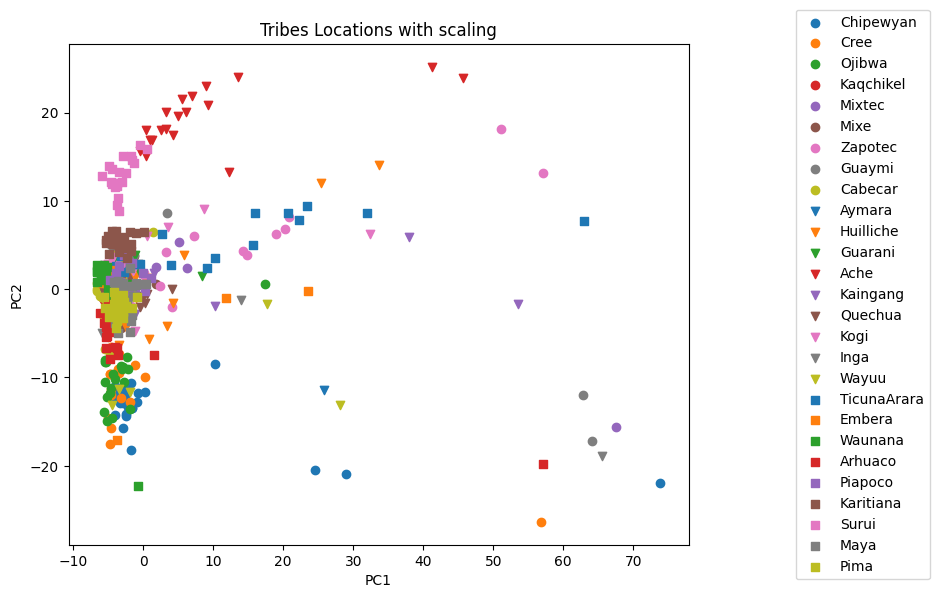

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

#PCA
pca = PCA(n_components=2)
pca.fit(X_std)
reduced_X = pca.transform(X_std)

#plotting

fig, ax = plt.subplots(figsize=(8.0, 6.5))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    idx = (df.iloc[:, 2] == tribe)
    ax.scatter(reduced_X[idx, 0], reduced_X[idx, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations with scaling')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()

The clusters are less defined .


**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

In this context, the genetic markers only have binary values, so we don't have a scaling problem .

Therefore, standarizing the data points will aonly amplify the genetic mutations that are so rare( which can be considered as noise) compared to ones that
are so frequent .

We conclude that standarizing the data points is not necesary for this TP .

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Variance captured by first 2 PCs: 3.57%
Components for 80% variance: 272
Components for 90% variance: 354


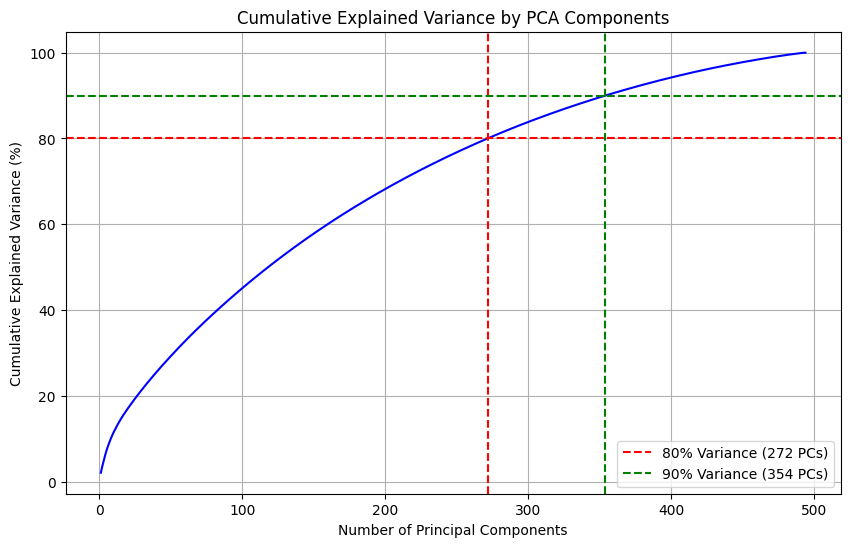

In [ ]:
# Fit PCA on the full unstandardized data (keeping all components, max is 494)
pca_full = PCA()
pca_full.fit(X)

# 1. Variance of the first two components
var_first_two = np.sum(pca_full.explained_variance_ratio_[:2]) * 100
print(f"Variance captured by first 2 PCs: {var_first_two:.2f}%")

# 2. Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

# 3. Find the number of components needed for 80% and 90% variance
comp_80 = np.argmax(cumulative_variance >= 80.0) + 1
comp_90 = np.argmax(cumulative_variance >= 90.0) + 1
print(f"Components for 80% variance: {comp_80}")
print(f"Components for 90% variance: {comp_90}")

# 4. Plot the cumulative variance (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linestyle='-', color='b')

# Add visual lines for 80% and 90% thresholds
plt.axhline(y=80, color='r', linestyle='--', label=f'80% Variance ({comp_80} PCs)')
plt.axvline(x=comp_80, color='r', linestyle='--')
plt.axhline(y=90, color='g', linestyle='--', label=f'90% Variance ({comp_90} PCs)')
plt.axvline(x=comp_90, color='g', linestyle='--')

plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

if we want to capture from 80% to 90% of the variance we need at least 272 PCs .

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

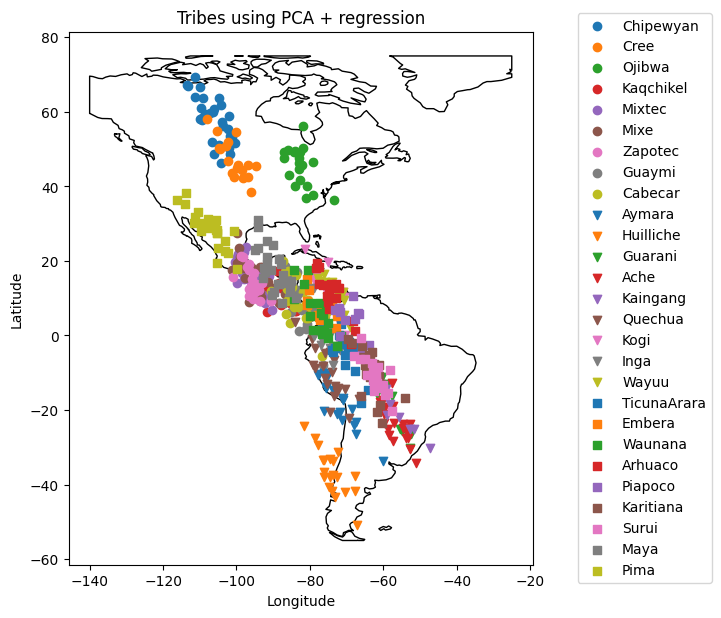

In [41]:
#Calculating the first 250 PCA
pca = PCA(n_components=250)
X_reduced = pca.fit_transform(X)

#Linear regression on the first 250 PCA
#Latitude
lr = LinearRegression()
lr.fit(X_reduced, latitude)
estimated_lat = lr.predict(X_reduced)
#Longitude
lr.fit(X_reduced, longitude)
estimated_long = lr.predict(X_reduced)

#plotting the data 
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the base map
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

# Set up the figure
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

# Plot the map background, clipped to the specific region
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

# Plotting the predicted points
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf['Pop'].unique()):
    # Get the boolean mask for the current tribe
    idx = (gdf['Pop'] == tribe) 
    
    # Scatter plot using the PREDICTED coordinates (estimated_long, estimated_lat)
    ax.scatter(estimated_long[idx], estimated_lat[idx], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

# Formatting the plot
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes using PCA + regression')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [17]:
from sklearn.metrics.pairwise import haversine_distances
def calculate_mean_error(X, Y):
    #Calculculating the error
    earth_radius =  6371000/1000
    mean_error = np.mean(np.diag(haversine_distances(np.radians(X), np.radians(Y)) * earth_radius))
    return mean_error

#Creating the coordinates
real_cord = np.column_stack((latitude, longitude))
pred_cord = np.column_stack((estimated_lat, estimated_long))
mean_error = calculate_mean_error(real_cord, pred_cord)

print(f"the mean error using linear regression  = {mean_error}  km")

the mean error using linear regression  = 637.9204611987517  km


The map and error calculation are too optimistic. This is because the linear regression was trained and evaluated on the exact same dataset. In statistical learning, this measures "training error" (resubstitution error), which does not account for the model's ability to generalize to new, unseen individuals.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

The principle of cross validation is instead of training data and testing it once ( on some training set and data set), we do the procedure multiple times
on different training sets and data sets , i.e folds .

Applying this procedure gives us an overall performance of the model on different folds which can help us escape overfitting and underfitting problems and better hyperparameters tuning .

One way to handle the case where the sample are not iid is to use GROUP K-Fold, or Stratified Group  K-fold .




**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Based in the skit learn documentation, the best cross_validation iterator in our case is the group K-Fold iterator .

In fact, our data samples are not IID ( people from same tribes have more genetics markers in common), so if we have individuals from the same tribe both
in the training set and in the test set , it is highly possible we have a leaking of information and as a result memorizing the data and overfitting instead
of learning the general pattern .

Cross validation K-Fold escapes this problem, by ensuring the same tribe isn't present twice in the training et testing set .


**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold
Y = np.column_stack((latitude, longitude))

def error_by_pca(n) :
    test_error = 0
    train_error = 0
    #building the pipeline
    pca = PCA(n_components=n)
    lr = LinearRegression()
    est = make_pipeline(pca, lr)

    #cretaing the kfold
    gkf = GroupKFold(n_splits=5)
    for train_idx, test_idx in gkf.split(X, Y, groups=tribes):

        #Creating the train set and test set
        X_train, Y_train = X[train_idx], Y[train_idx]
        X_test, Y_test = X[test_idx], Y[test_idx]

        #fitting the pipeline
        est.fit(X_train, Y_train)

        #predicting lattitude and longitude
        predicted_train_cord = est.predict(X_train)
        predicted_test_cord = est.predict(X_test)

        #calculating mean error
        mean_split_train_error = calculate_mean_error(Y_train, predicted_train_cord)
        mean_split_test_error = calculate_mean_error(Y_test, predicted_test_cord)

        #overall error
        train_error += mean_split_train_error
        test_error += mean_split_test_error

    return  train_error/5, test_error/5


train_error, test_error = error_by_pca(4)
print(f"For n_components = {4} the train error = {train_error}, test error = {test_error}")


For n_components = 4 the train error = 1797.0896144252474, test error = 2517.7725887842184


(d) Repeat the analysis from item (b) but changing n_components between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

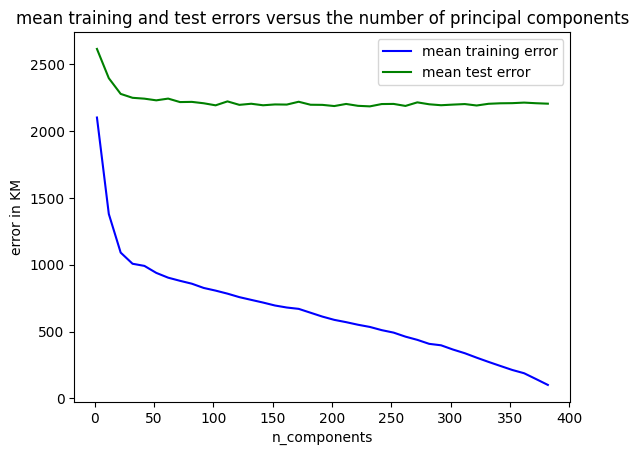

In [48]:
#initializing the arrays
n_components = []
mean_training_error = []
mean_test_error =  []

#Calculations and filling the arrays

for k in range(2, 390, 10):
    n_components.append(k)
    train_error, test_error = error_by_pca(k)
    mean_training_error.append(train_error)
    mean_test_error.append(test_error)

plt.plot(n_components, mean_training_error, label= "mean training error", c= "blue")
plt.plot(n_components, mean_test_error, label= "mean test error", c = "green")
plt.xlabel ("n_components")
plt.ylabel("error in KM")
plt.legend()
plt.title("mean training and test errors versus the number of principal components")
plt.show()


**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

232
2184.0259238195076
534.2964361595982


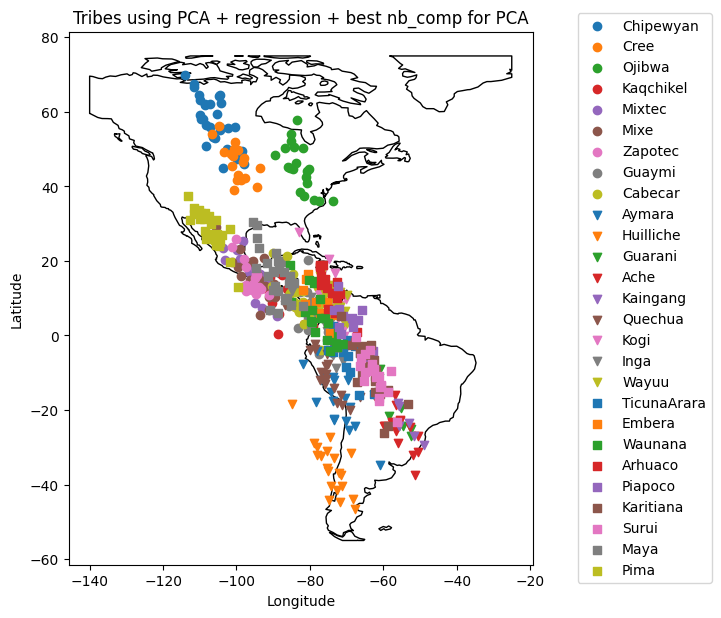

In [49]:
#finding the model with n_components that minimizes the test error
idx_best_k = np.argmin(mean_test_error)
print(n_components[idx_best_k])

#printing the predection error for this model
print(mean_test_error[idx_best_k])

#printing the correspending training error
print(mean_training_error[idx_best_k])

best_k = n_components[idx_best_k]

#defining the pipeline
pca = PCA(n_components=best_k)
lr = LinearRegression()
est = make_pipeline(pca, lr)

#fitting the model and doing predictions
est.fit(X, Y)
estimated_cord = est.predict(X)


# Load the base map
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

# Set up the figure
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

# Plot the map background, clipped to the specific region
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

# Plotting the predicted points
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf['Pop'].unique()):
    # Get the boolean mask for the current tribe
    idx = (gdf['Pop'] == tribe) 
    
    # Scatter plot using the PREDICTED coordinates (estimated_long, estimated_lat)
    ax.scatter(estimated_cord[idx, 1], estimated_cord[idx, 0], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

# Formatting the plot
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes using PCA + regression + best nb_comp for PCA')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()





We will keep the model with n_components = 232 because it offers the minimal test_error .

The mean training error and mean test error are respectively : 534.2964361595982km , 2184.0259238195076km


The two plots (this one and the one from Exercice 4(a)) doesn't differ so much .

This is due to the fact that visual presentation are always a good metrics .

On the other hand, doing cross validation helped us view how the model performs under different hyperparameters .

We have mean training error which is always decreasing because we train our data on the training set . But the test error plot shows two parts : 
The first part the error drops and then increases due to overfitting .

This minimum is the one we chose as the number of components to have a compromise between the variance of the model and its bias .

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In this study, we used Principal Component Regression to predict the geographic coordinates (latitude and longitude) of individuals from high-dimensional genetic markers. Because the number of genetic variables is very large compared to the number of samples, dimensionality reduction using Principal Component Analysis was necessary before applying linear regression.

The results show that the predictive performance strongly depends on the number of principal components used. With too few components, the model underfits because it does not capture enough genetic variability. As the number of components increases, the prediction error decreases since more information from the genetic data is incorporated into the regression. However, after a certain point the test error stabilizes, indicating that additional components mostly represent noise rather than useful structure. The optimal predictive model therefore corresponds to the number of components that minimizes the test error.

The model demonstrates that genetic markers contain meaningful information about the geographic origin of individuals, allowing reasonably accurate prediction of latitude and longitude. Nevertheless, prediction performance may vary between countries due to differences in genetic diversity and population structure. Countries with more homogeneous genetic populations are expected to yield lower prediction errors than those with more heterogeneous populations.

A possible improvement to this approach would be to replace PCR with Partial Least Squares Regression, which constructs latent components that maximize the covariance between predictors and response variables. Unlike PCA, which focuses only on the variance of the predictors, PLS is specifically designed for predictive tasks and may therefore lead to improved accuracy.

In summary, PCR provides a reasonable predictive framework for this problem, but careful selection of the number of components and alternative methods such as PLS could further improve the quality of the predictions.